<a href="https://colab.research.google.com/github/anjalie03/sars-cov-2-spike-sequence-analysis/blob/main/spike_protein_variant_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Part 1: Setup
#Install tools

In [ ]:
!pip install biopython


In [ ]:
!pip install biopython -q
!apt-get install -y mafft -q
!mafft --version

Reading package lists...
Building dependency tree...
Reading state information...
mafft is already the newest version (7.505-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
v7.505 (2022/Apr/10)


2.Imports and folders

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Entrez, SeqIO, AlignIO, Phylo, Align
from Bio.Align import substitution_matrices
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.Phylo.TreeConstruction import DistanceCalculator, DistanceTreeConstructor

for d in ["data/raw", "data/processed", "results/figures", "results/tables"]:
    os.makedirs(d, exist_ok=True)

Entrez.email = "galandeanjali9@gmail.com"
sns.set_theme(style="whitegrid")

Part 2:Get the Data and define the sample
#SARS_COV_2 DATA

In [ ]:
samples = {
    "YP_009724390.1": "Reference_WuHan",   # leave as is
    "YGX71411.1": "Alpha_1",
    "YGX71422.1": "Alpha_2",
    "YGX71432.1": "Alpha_3",
    "YEN82282.1": "Delta_1",
    "YEN83538.1": "Delta_2",
    "YEN83550.1": "Delta_3",
    "YED35322.1": "Omicron_1",
    "YED35298.1": "Omicron_2",
    "YED35310.1": "Omicron_3",
}

#Download from NCBI (Spike proteins)

In [ ]:
handle = Entrez.efetch(db="protein", id=list(samples.keys()),
                       rettype="fasta", retmode="text")
raw = handle.read()
handle.close()

records = list(SeqIO.parse(__import__("io").StringIO(raw), "fasta"))

# Rename each record with a readable label, reference first
by_acc = {r.id: r for r in records}
ordered = []
for acc, label in samples.items():
    rec = by_acc[acc]
    rec.id = label
    rec.description = acc
    ordered.append(rec)

SeqIO.write(ordered, "data/raw/spike_proteins.fasta", "fasta")
for r in ordered:
    print(r.id, len(r.seq))

Reference_WuHan 1273
Alpha_1 1270
Alpha_2 1270
Alpha_3 1270
Delta_1 1271
Delta_2 1271
Delta_3 1273
Omicron_1 1270
Omicron_2 1270
Omicron_3 1270


Part 3: Sequence statistics
#Basic properties

In [ ]:
rows = []
for rec in ordered:
    seq = str(rec.seq).replace("X", "").replace("*", "")
    pa = ProteinAnalysis(seq)
    rows.append({
        "sample": rec.id,
        "length": len(seq),
        "mol_weight_Da": round(pa.molecular_weight(), 1),
        "isoelectric_point": round(pa.isoelectric_point(), 2),
        "instability_index": round(pa.instability_index(), 2),
        "gravy_hydrophobicity": round(pa.gravy(), 3),
    })

stats = pd.DataFrame(rows)
stats.to_csv("results/tables/sequence_stats.csv", index=False)
stats

,sample,length,mol_weight_Da,isoelectric_point,instability_index,gravy_hydrophobicity
0,Reference_WuHan,1273,141176.8,6.24,33.01,-0.079
1,Alpha_1,1209,134210.1,6.23,32.73,-0.079
2,Alpha_2,1266,140518.1,6.44,32.68,-0.080
3,Alpha_3,1241,137566.8,6.35,32.97,-0.080
4,Delta_1,1271,140996.7,6.78,33.00,-0.086
5,Delta_2,1251,138553.9,6.16,32.11,-0.075
6,Delta_3,1245,138234.6,6.32,32.58,-0.084
7,Omicron_1,1259,140077.1,7.35,35.16,-0.071
8,Omicron_2,1269,141170.3,6.96,34.80,-0.077
9,Omicron_3,1269,141170.3,6.96,34.80,-0.077


#Plot lengths and amino acid composition

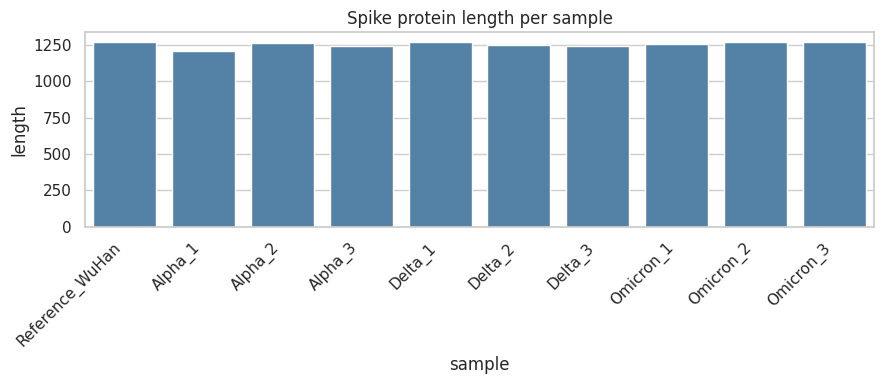

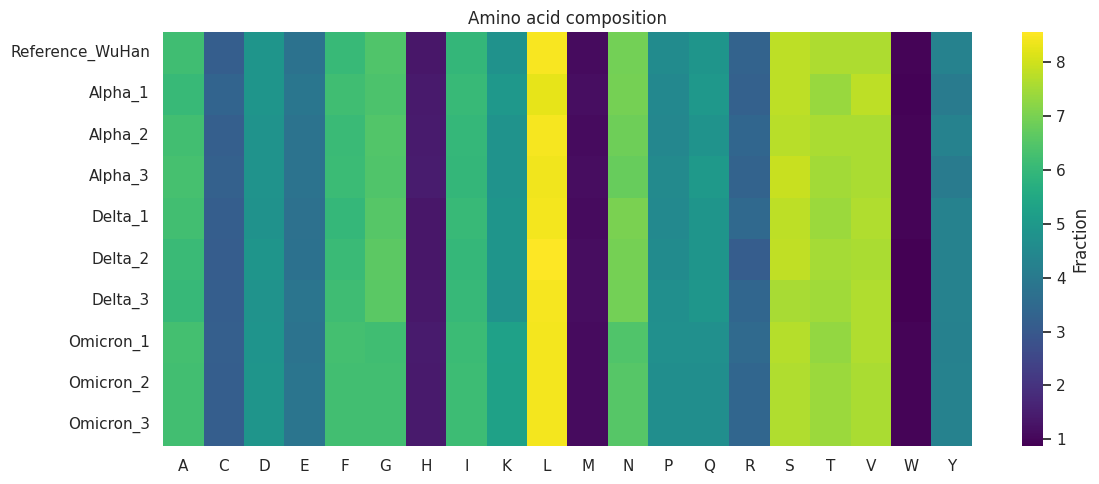

In [ ]:
# Length bar plot
plt.figure(figsize=(9, 4))
sns.barplot(data=stats, x="sample", y="length", color="steelblue")
plt.xticks(rotation=45, ha="right")
plt.title("Spike protein length per sample")
plt.tight_layout()
plt.savefig("results/figures/lengths.png", dpi=300)
plt.show()

# Amino acid composition heatmap
comp = {}
for rec in ordered:
    seq = str(rec.seq).replace("X", "").replace("*", "")
    comp[rec.id] = ProteinAnalysis(seq).amino_acids_percent
comp_df = pd.DataFrame(comp).T

plt.figure(figsize=(12, 5))
sns.heatmap(comp_df, cmap="viridis", cbar_kws={"label": "Fraction"})
plt.title("Amino acid composition")
plt.tight_layout()
plt.savefig("results/figures/aa_composition.png", dpi=300)
plt.show()

Part 4: Pairwise alignment against the reference
#Align each variant to the reference

In [ ]:
aligner = Align.PairwiseAligner()
aligner.mode = "global"
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5

ref_seq = str(ordered[0].seq)
results = []
for rec in ordered[1:]:
    best = aligner.align(ref_seq, str(rec.seq))[0]
    c = best.counts()
    results.append({
        "sample": rec.id,
        "score": best.score,
        "identities": c.identities,
        "mismatches": c.mismatches,
        "gaps": c.gaps,
        "percent_identity": round(100 * c.identities / len(ref_seq), 2),
    })

pw = pd.DataFrame(results)
pw.to_csv("results/tables/pairwise_vs_reference.csv", index=False)
pw

,sample,score,identities,mismatches,gaps,percent_identity
0,Alpha_1,6269.5,1202,68,3,94.42
1,Alpha_2,6606.5,1258,12,3,98.82
2,Alpha_3,6457.5,1234,36,3,96.94
3,Delta_1,6641.5,1262,9,2,99.14
4,Delta_2,6536.5,1245,26,2,97.80
5,Delta_3,6530.0,1240,33,0,97.41
6,Omicron_1,6403.5,1226,41,9,96.31
7,Omicron_2,6465.5,1236,31,9,97.09
8,Omicron_3,6465.5,1236,31,9,97.09


Part 5: Multiple sequence alignment
#Run MAFFT

In [ ]:
!mafft --auto --quiet data/raw/spike_proteins.fasta > data/processed/spike_aligned.fasta

#Load and inspect

In [ ]:
aln = AlignIO.read("data/processed/spike_aligned.fasta", "fasta")
print("Sequences:", len(aln))
print("Alignment length:", aln.get_alignment_length())

Sequences: 10
Alignment length: 1276


Part 6: Mutation detection
#Find substitutions relative to the reference

In [ ]:
ref_rec = next(r for r in aln if r.id == "Reference_WuHan")
ref = str(ref_rec.seq)

mutations = []
for record in aln:
    if record.id == "Reference_WuHan":
        continue
    var = str(record.seq)
    ref_pos = 0
    for r, v in zip(ref, var):
        if r != "-":
            ref_pos += 1
        if r != "-" and v != "-" and r != v:
            mutations.append({
                "sample": record.id,
                "lineage": record.id.split("_")[0],
                "position": ref_pos,
                "ref": r, "alt": v,
                "mutation": f"{r}{ref_pos}{v}",
            })

mut_df = pd.DataFrame(mutations)
mut_df.to_csv("results/tables/mutations.csv", index=False)
print(mut_df.groupby("sample").size())
mut_df.head(15)

sample
Alpha_1      68
Alpha_2      12
Alpha_3      36
Delta_1       9
Delta_2      26
Delta_3      33
Omicron_1    41
Omicron_2    31
Omicron_3    31
dtype: int64


,sample,lineage,position,ref,alt,mutation
0,Alpha_1,Alpha,229,L,X,L229X
1,Alpha_1,Alpha,230,P,X,P230X
2,Alpha_1,Alpha,231,I,X,I231X
3,Alpha_1,Alpha,232,G,X,G232X
4,Alpha_1,Alpha,233,I,X,I233X
5,Alpha_1,Alpha,234,N,X,N234X
6,Alpha_1,Alpha,235,I,X,I235X
7,Alpha_1,Alpha,236,T,X,T236X
8,Alpha_1,Alpha,237,R,X,R237X
9,Alpha_1,Alpha,238,F,X,F238X


#Check known mutations

In [ ]:
known = ["D614G", "N501Y", "L452R", "T478K", "E484A", "K417N", "P681R", "P681H"]
present = mut_df.groupby("mutation")["lineage"].agg(lambda x: sorted(set(x)))
for m in known:
    print(m, "->", present.get(m, "not found"))

D614G -> ['Alpha', 'Delta', 'Omicron']
N501Y -> ['Alpha', 'Omicron']
L452R -> ['Delta']
T478K -> ['Delta', 'Omicron']
E484A -> ['Omicron']
K417N -> ['Omicron']
P681R -> ['Delta']
P681H -> ['Alpha', 'Omicron']


#Plot mutation count per lineage

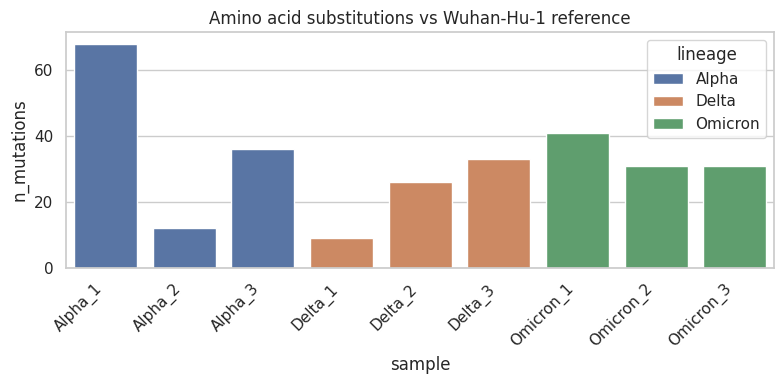

In [ ]:
counts = mut_df.groupby("sample").size().reset_index(name="n_mutations")
counts["lineage"] = counts["sample"].str.split("_").str[0]

plt.figure(figsize=(8, 4))
sns.barplot(data=counts, x="sample", y="n_mutations", hue="lineage", dodge=False)
plt.xticks(rotation=45, ha="right")
plt.title("Amino acid substitutions vs Wuhan-Hu-1 reference")
plt.tight_layout()
plt.savefig("results/figures/mutation_counts.png", dpi=300)
plt.show()

#Plot mutation count per lineage

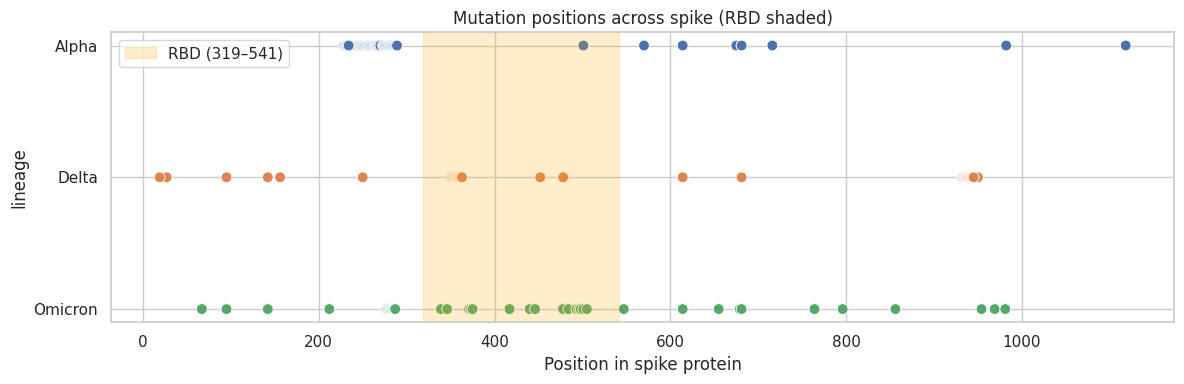

lineage
Alpha       1
Delta      16
Omicron    16
Name: mutation, dtype: int64


In [ ]:
plt.figure(figsize=(12, 4))
sns.scatterplot(data=mut_df, x="position", y="lineage", hue="lineage",
                s=60, legend=False)
plt.axvspan(319, 541, color="orange", alpha=0.2, label="RBD (319–541)")
plt.xlabel("Position in spike protein")
plt.title("Mutation positions across spike (RBD shaded)")
plt.legend()
plt.tight_layout()
plt.savefig("results/figures/mutation_map.png", dpi=300)
plt.show()

rbd = mut_df[(mut_df.position >= 319) & (mut_df.position <= 541)]
print(rbd.groupby("lineage")["mutation"].nunique())

Part 7: Phylogenetic tree
#Neighbor-joining tree (pure Python)

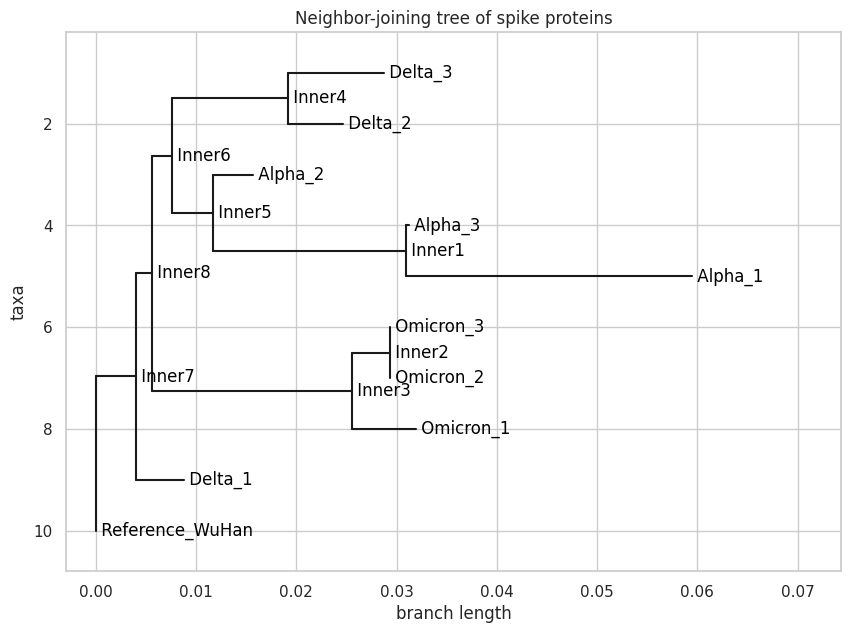

In [ ]:
calc = DistanceCalculator("blosum62")
dm = calc.get_distance(aln)
tree = DistanceTreeConstructor().nj(dm)
tree.root_with_outgroup("Reference_WuHan")

fig, ax = plt.subplots(figsize=(10, 7))
Phylo.draw(tree, axes=ax, do_show=False)
plt.title("Neighbor-joining tree of spike proteins")
plt.savefig("results/figures/nj_tree.png", dpi=300, bbox_inches="tight")
plt.show()

#Maximum likelihood with IQ-TREE

In [ ]:
!apt-get install -y iqtree -q
!which iqtree iqtree2

Reading package lists...
Building dependency tree...
Reading state information...
iqtree is already the newest version (2.0.7+dfsg-1build2).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
/usr/bin/iqtree2


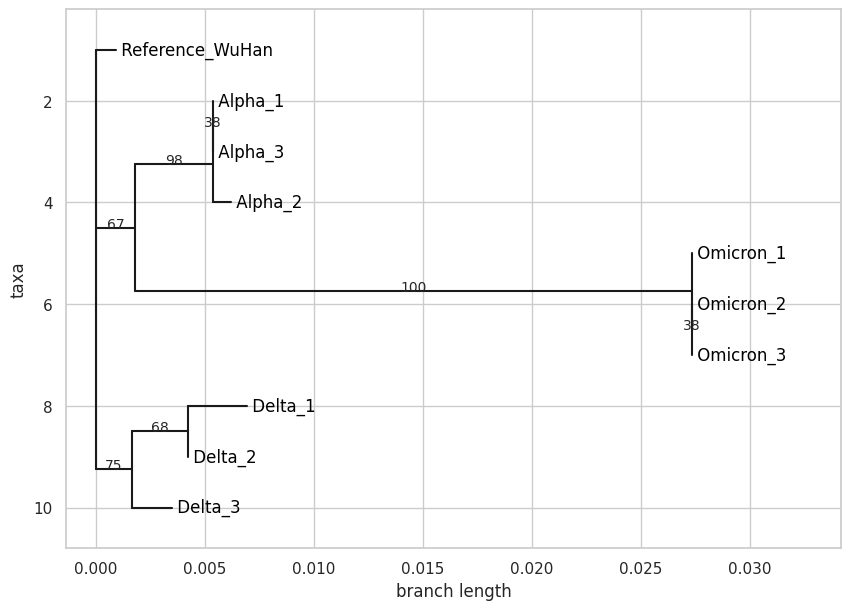

In [ ]:
t = Phylo.read("data/processed/spike_aligned.fasta.treefile", "newick")
fig, ax = plt.subplots(figsize=(10, 7))
Phylo.draw(t, axes=ax, do_show=False)
plt.savefig("results/figures/ml_tree.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
!ls data/processed

spike_aligned.fasta	     spike_aligned.fasta.log
spike_aligned.fasta.bionj    spike_aligned.fasta.mldist
spike_aligned.fasta.ckp.gz   spike_aligned.fasta.model.gz
spike_aligned.fasta.contree  spike_aligned.fasta.splits.nex
spike_aligned.fasta.iqtree   spike_aligned.fasta.treefile


In [ ]:
!apt-get install -y iqtree -q
!which iqtree iqtree2

Reading package lists...
Building dependency tree...
Reading state information...
iqtree is already the newest version (2.0.7+dfsg-1build2).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
/usr/bin/iqtree2


In [ ]:
!iqtree2 -s data/processed/spike_aligned.fasta -m TEST -bb 1000 -nt AUTO -redo

IQ-TREE multicore version 2.0.7 for Linux 64-bit built Apr  1 2024
Developed by Bui Quang Minh, Nguyen Lam Tung, Olga Chernomor,
Heiko Schmidt, Dominik Schrempf, Michael Woodhams.

Host:    cb9eefc3a799 (AVX2, FMA3, 12 GB RAM)
Command: iqtree2 -s data/processed/spike_aligned.fasta -m TEST -bb 1000 -nt AUTO -redo
Seed:    738203 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Wed Sep 30 12:06:23 2026
Kernel:  AVX+FMA - auto-detect threads (2 CPU cores detected)

Reading alignment file data/processed/spike_aligned.fasta ... Fasta format detected
Alignment most likely contains protein sequences
Alignment has 10 sequences with 1276 columns, 126 distinct patterns
37 parsimony-informative, 3 singleton sites, 1236 constant sites
                 Gap/Ambiguity  Composition  p-value
   1  Reference_WuHan    0.24%    passed    100.00%
   2  Alpha_1            5.25%    passed    100.00%
   3  Alpha_2            0.78%    passed    100.00%
   4  Alpha_3            2.74%    passed

In [ ]:
!ls data/processed

spike_aligned.fasta	     spike_aligned.fasta.log
spike_aligned.fasta.bionj    spike_aligned.fasta.mldist
spike_aligned.fasta.ckp.gz   spike_aligned.fasta.model.gz
spike_aligned.fasta.contree  spike_aligned.fasta.splits.nex
spike_aligned.fasta.iqtree   spike_aligned.fasta.treefile


In [ ]:
!ls results/figures results/tables data/processed

data/processed:
spike_aligned.fasta	     spike_aligned.fasta.log
spike_aligned.fasta.bionj    spike_aligned.fasta.mldist
spike_aligned.fasta.ckp.gz   spike_aligned.fasta.model.gz
spike_aligned.fasta.contree  spike_aligned.fasta.splits.nex
spike_aligned.fasta.iqtree   spike_aligned.fasta.treefile

results/figures:
aa_composition.png  ml_tree.png		 mutation_map.png
lengths.png	    mutation_counts.png  nj_tree.png

results/tables:
mutations.csv  pairwise_vs_reference.csv  sequence_stats.csv


Part 8: Save your work
#Download results

In [ ]:
!zip -r results.zip results data/processed data/accessions.csv -q
from google.colab import files
files.download("results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>